In [1]:
import numpy as np
from samplers.SEIR_emcee import SEIR_emcee
from samplers.SEIR_pytwalk import SEIR_pytwalk
from samplers.SEIR_pyhmc import SEIR_pyhmc
from epidemic_model import SEIR_Model
from utils.utils import load_data, parser
import sys
import matplotlib.pyplot as plt
from time import time
from joblib import dump, load

In [2]:
from bokeh.io import output_notebook, show

output_notebook()

Loading BokehJS ...

Data loaded from file:  data/Smoothed_Cases_Third_Wave.csv


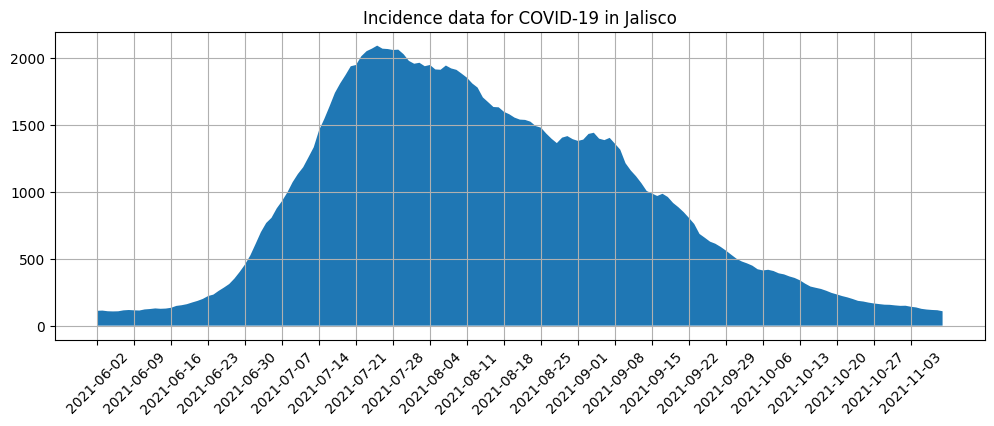

In [3]:
# Loading configuration from configuration file
fname_conf = './configuration_file_test.cfg'

params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [4]:
print(dates[0], dates[-1])
print(np.sum(data))

2021-06-02 2021-11-09
144769.7142857143


In [5]:
# Total population size is taken from the configuration file
N = params["N"]

# Setting initial conditions
E0 = data[0] 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

iterations = params['iterations']  # Number of iterations for the MCMC sampler
ndim = 3                           # Dimension of the problem is 3: beta, sigma, gamma

reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']


In [6]:

#### Run this cell in case that are loading a previous run
if reload_flag :
    seir_twalk = load(outpath+'/twalk/'+out_file)
    seir_twalk.outpath = outpath

In [7]:
if not reload_flag :
        seir_twalk = SEIR_pytwalk(
                ndim=ndim,
                data=data,
                time=times,
                x0=x0,
                labels=['beta', 'sigma', 'gamma'],
                **params
                )

        xp0 = np.array([0.36,0.98,0.2])
        xp1 = np.array([0.5,1.00,0.15])


In [ ]:
if not reload_flag :
    ini_time = time()
    seir_twalk.run(iterations,xp0,xp1)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)

    dump(seir_twalk, outpath+'/pytwalk/'+out_file)

pytwalk: Running the twalk to 10000 iterations .  Fri, 11 Apr 2025, 21:05:52.
       Finish in approx. 3 min and 8 sec.


/opt/conda/envs/bnn-env/lib/python3.11/site-packages/pytwalk/pytwalk.py:577: RuntimeWarning: overflow encountered in exp
  A = exp(u - u_prop)
/opt/conda/envs/bnn-env/lib/python3.11/site-packages/pytwalk/pytwalk.py:563: RuntimeWarning: overflow encountered in exp
  A = exp(up - up_prop)
/opt/conda/envs/bnn-env/lib/python3.11/site-packages/pytwalk/pytwalk.py:602: RuntimeWarning: overflow encountered in exp
  A = exp((up - up_prop) +  (self.nphi-2)*log(beta))
/opt/conda/envs/bnn-env/lib/python3.11/site-packages/pytwalk/pytwalk.py:686: RuntimeWarning: overflow encountered in exp
  A = exp((u - u_prop) + (W1 - W2))
/opt/conda/envs/bnn-env/lib/python3.11/site-packages/pytwalk/pytwalk.py:619: RuntimeWarning: overflow encountered in exp
  A = exp((u - u_prop) +  (self.nphi-2)*log(beta))


pytwalk:       2047 iterations so far. Finish in approx. 2 min and 21 sec.
pytwalk:       6143 iterations so far. Finish in approx. 1 min and 9 sec.
pytwalk: finished, 10000 iterations.
Fri, 11 Apr 2025, 21:08:53.
Time elapsed:  181.044917345047


In [14]:
seir_twalk.create_dictionary()

In [15]:
seir_twalk.summary()


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.403  0.041   0.379    0.503      0.015    0.011       4.0      33.0   
sigma  0.058  0.083   0.044    0.049      0.008    0.035      16.0      36.0   
gamma  0.061  0.018   0.051    0.082      0.006    0.006       5.0       9.0   

       r_hat  
beta    1.41  
sigma   1.17  
gamma   1.29  


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.403  0.041   0.379    0.503      0.015    0.011       4.0      33.0   
sigma  0.058  0.083   0.044    0.049      0.008    0.035      16.0      36.0   
gamma  0.061  0.018   0.051    0.082      0.006    0.006       5.0       9.0   

       r_hat  
beta    1.41  
sigma   1.17  
gamma   1.29  


<Figure size 640x480 with 0 Axes>

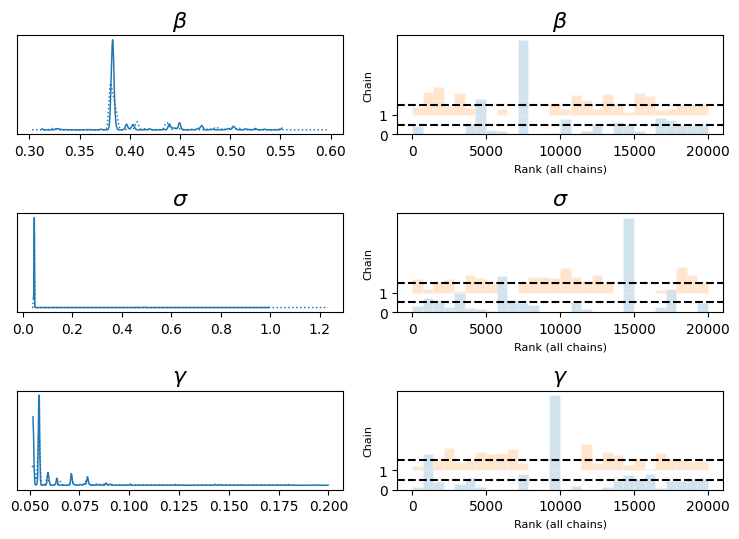

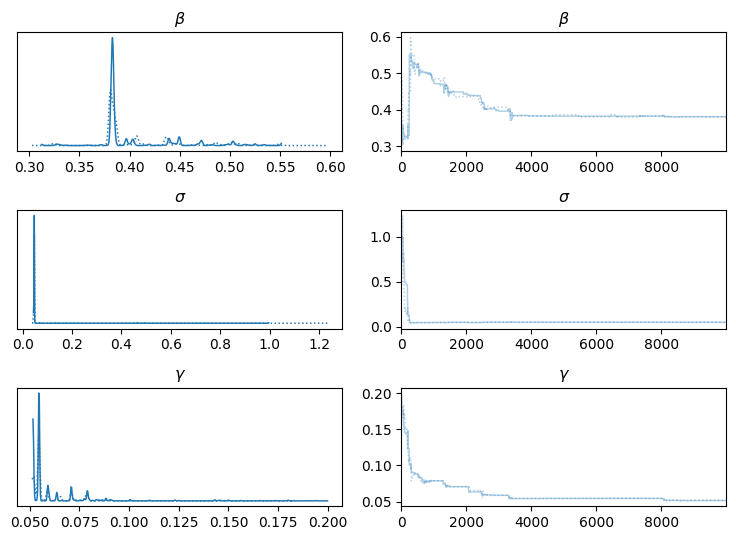

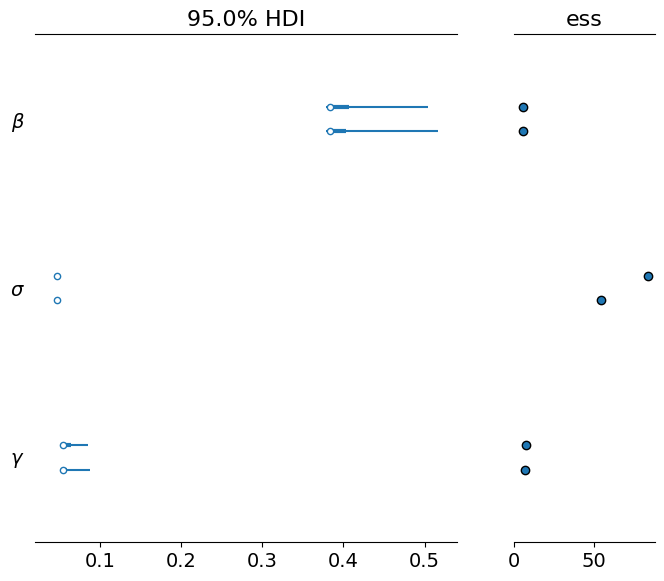

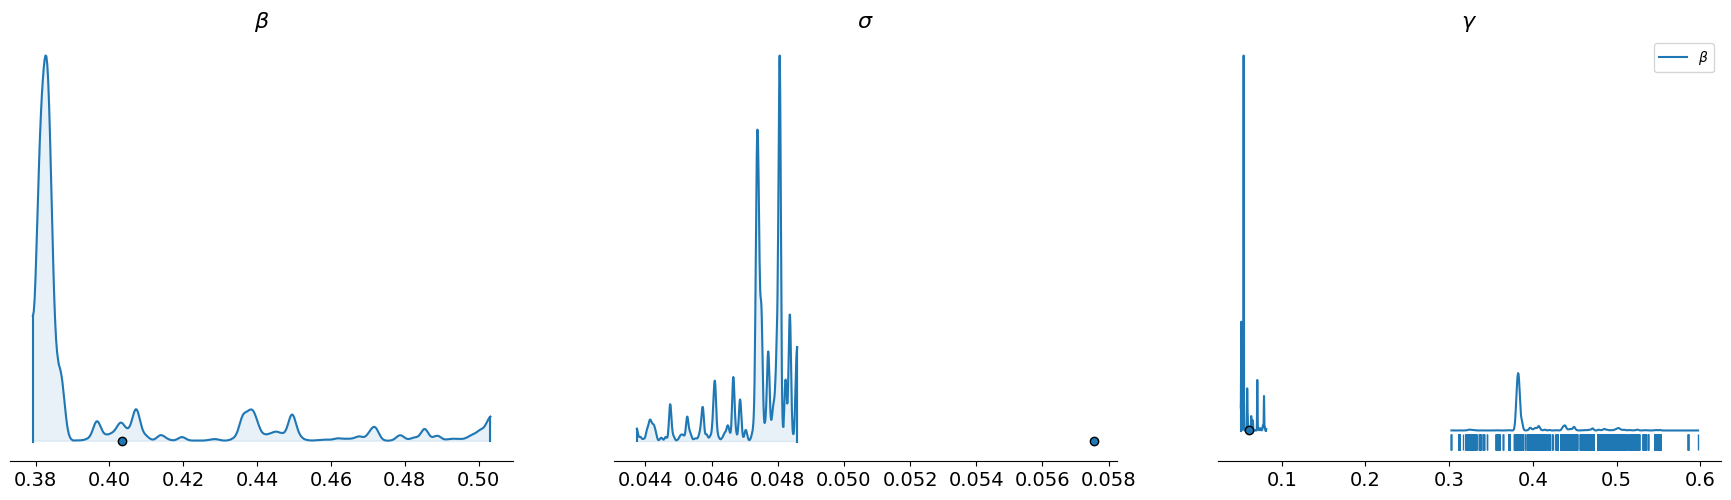

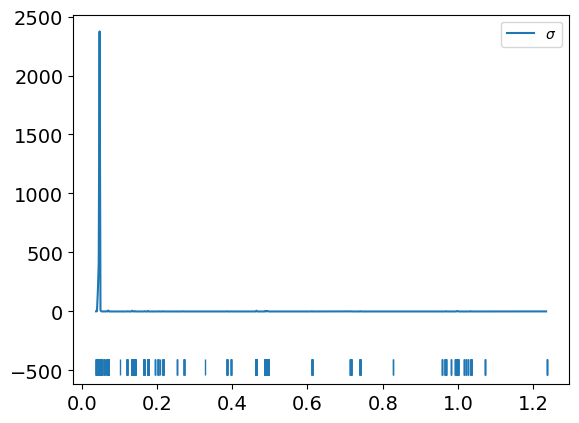

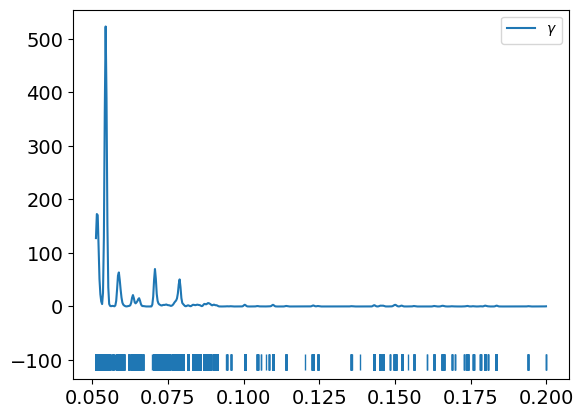

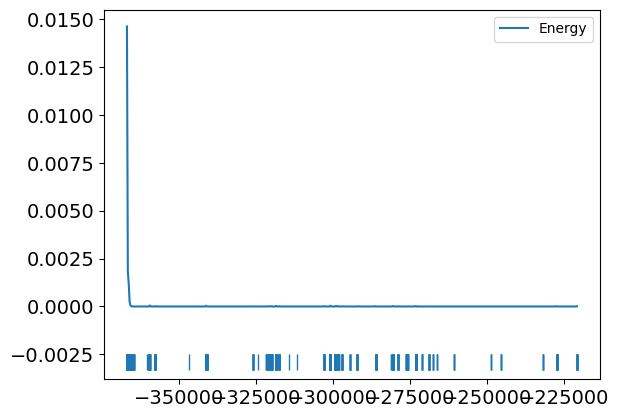

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 4999 samples


100%|██████████| 9998/9998 [02:57<00:00, 56.21it/s]


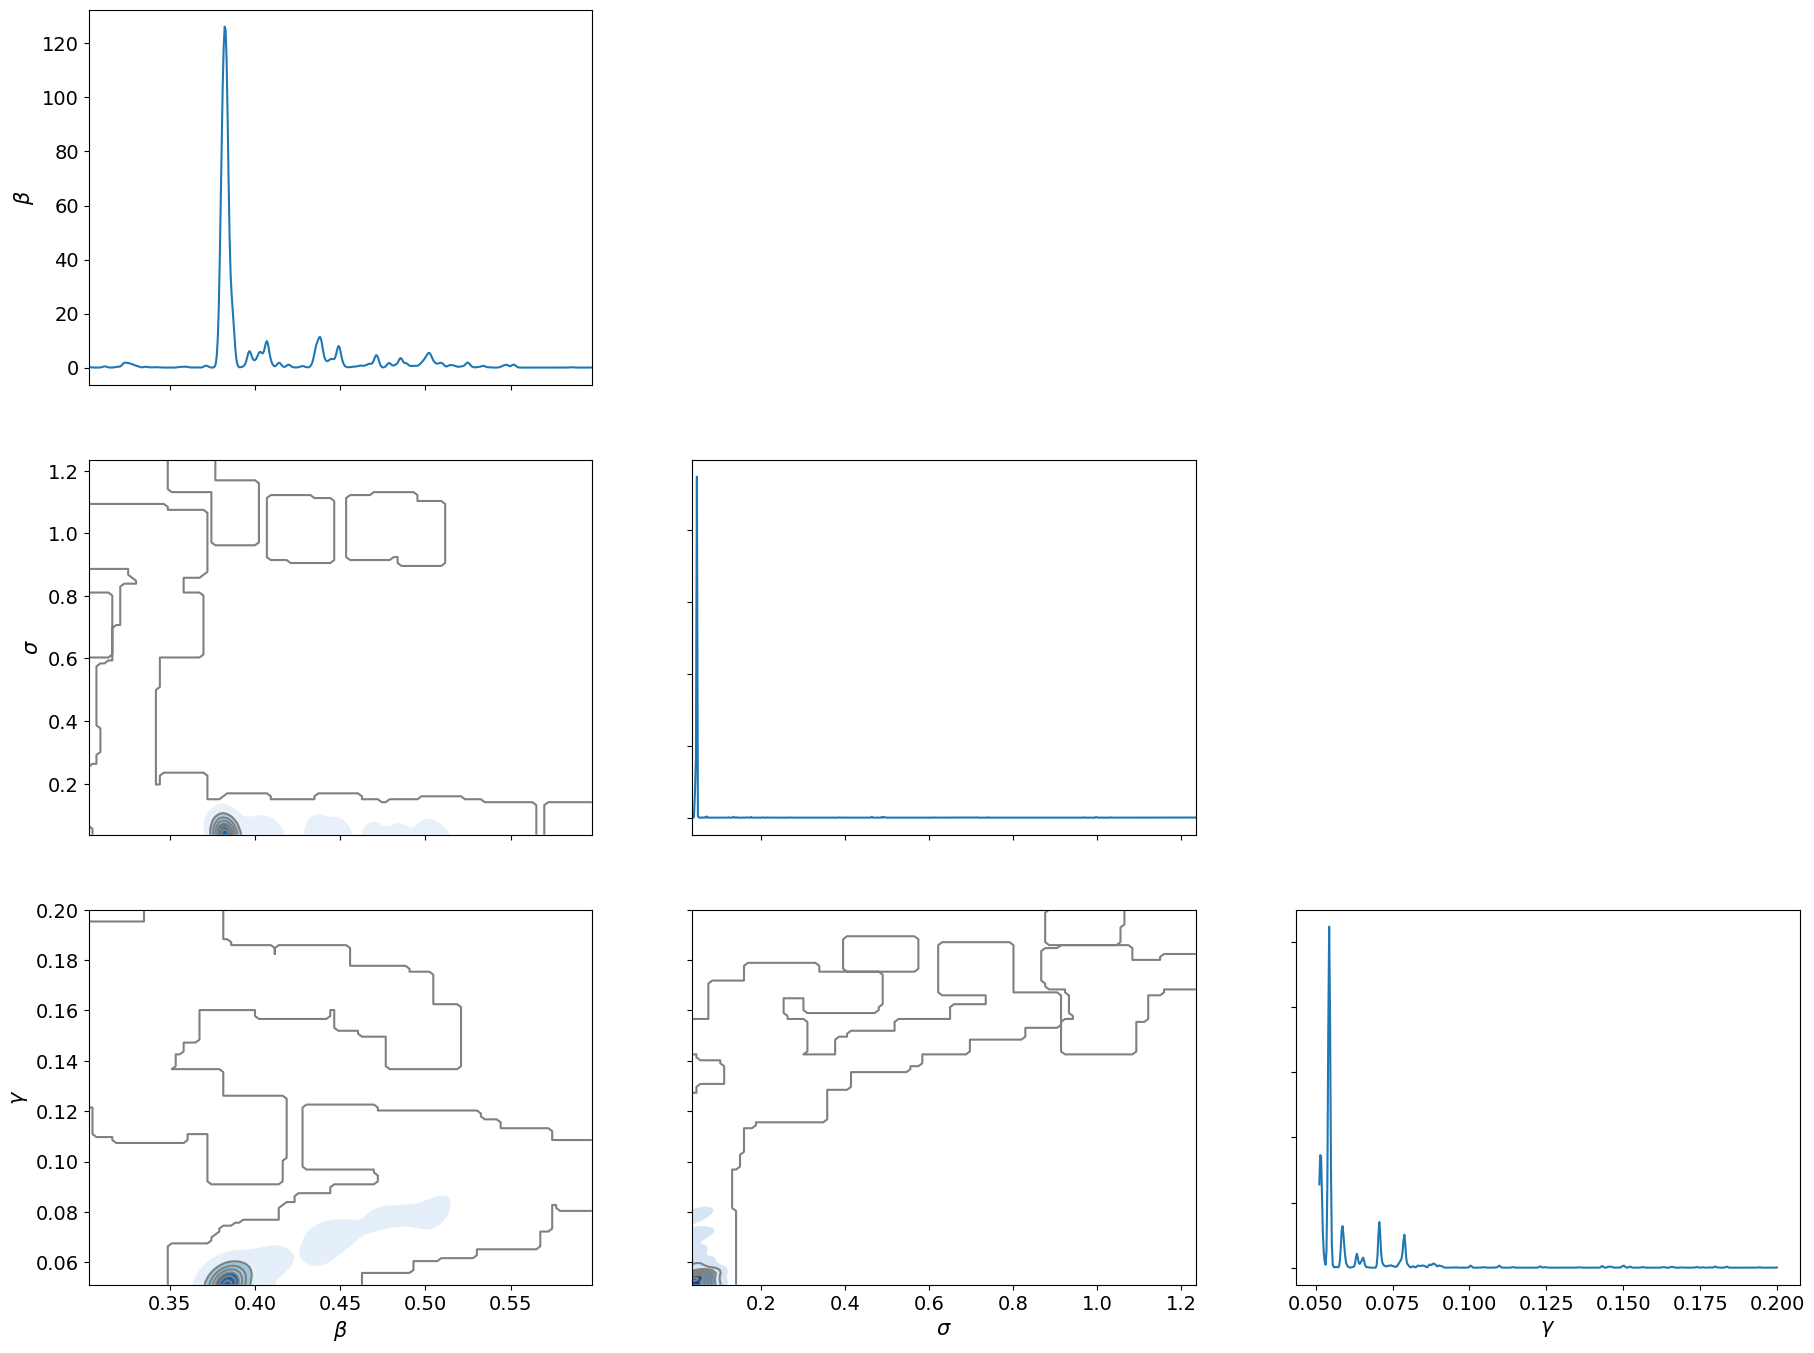

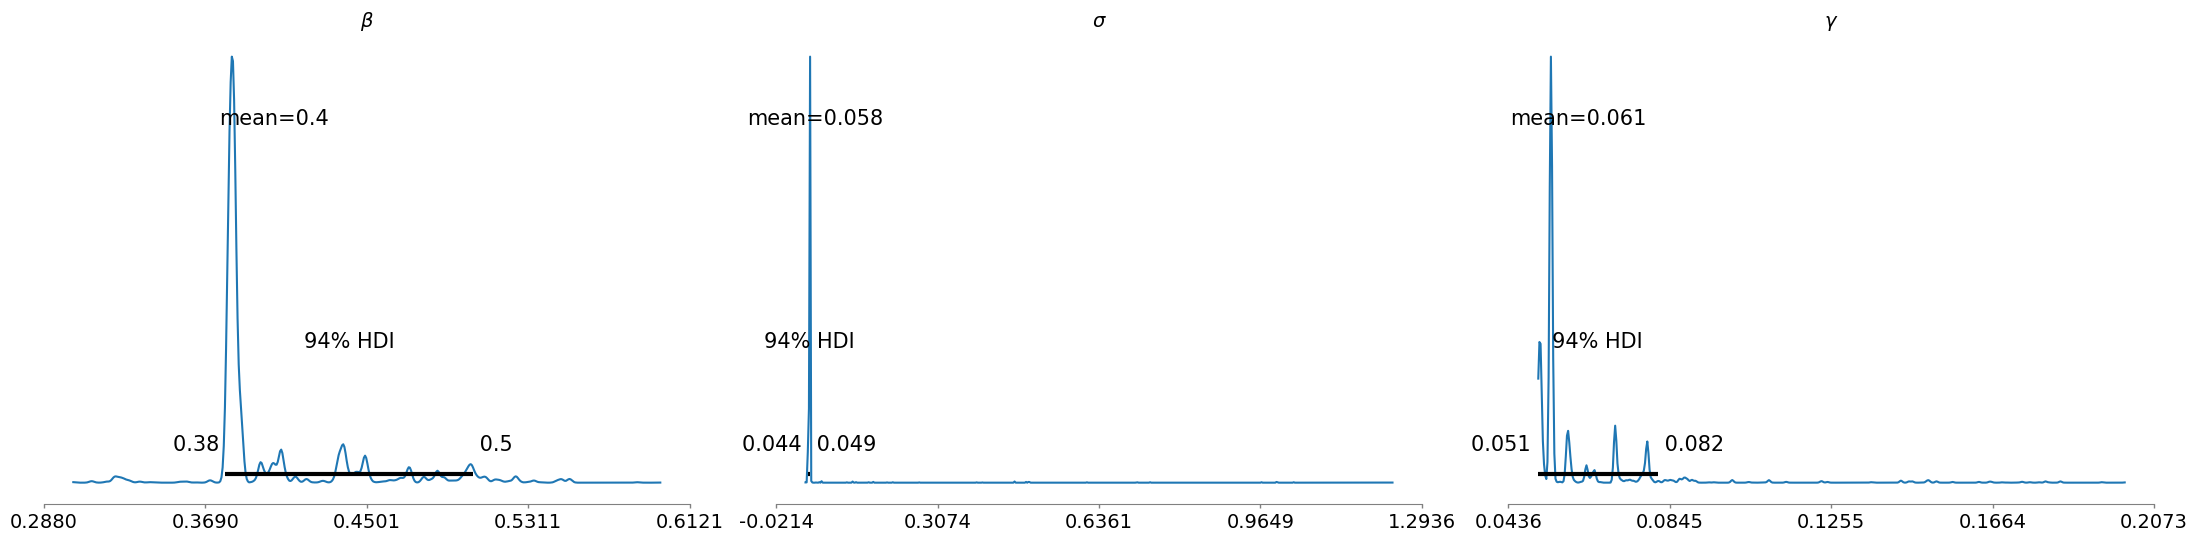

/opt/conda/envs/bnn-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


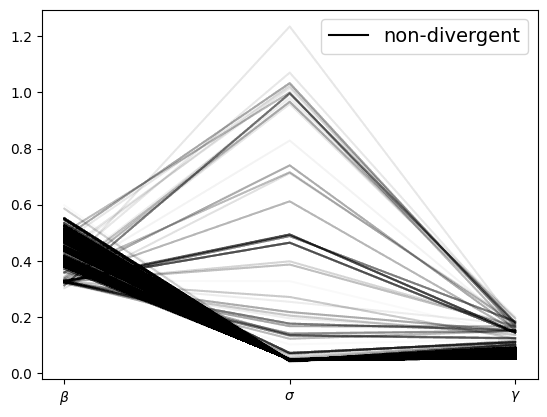

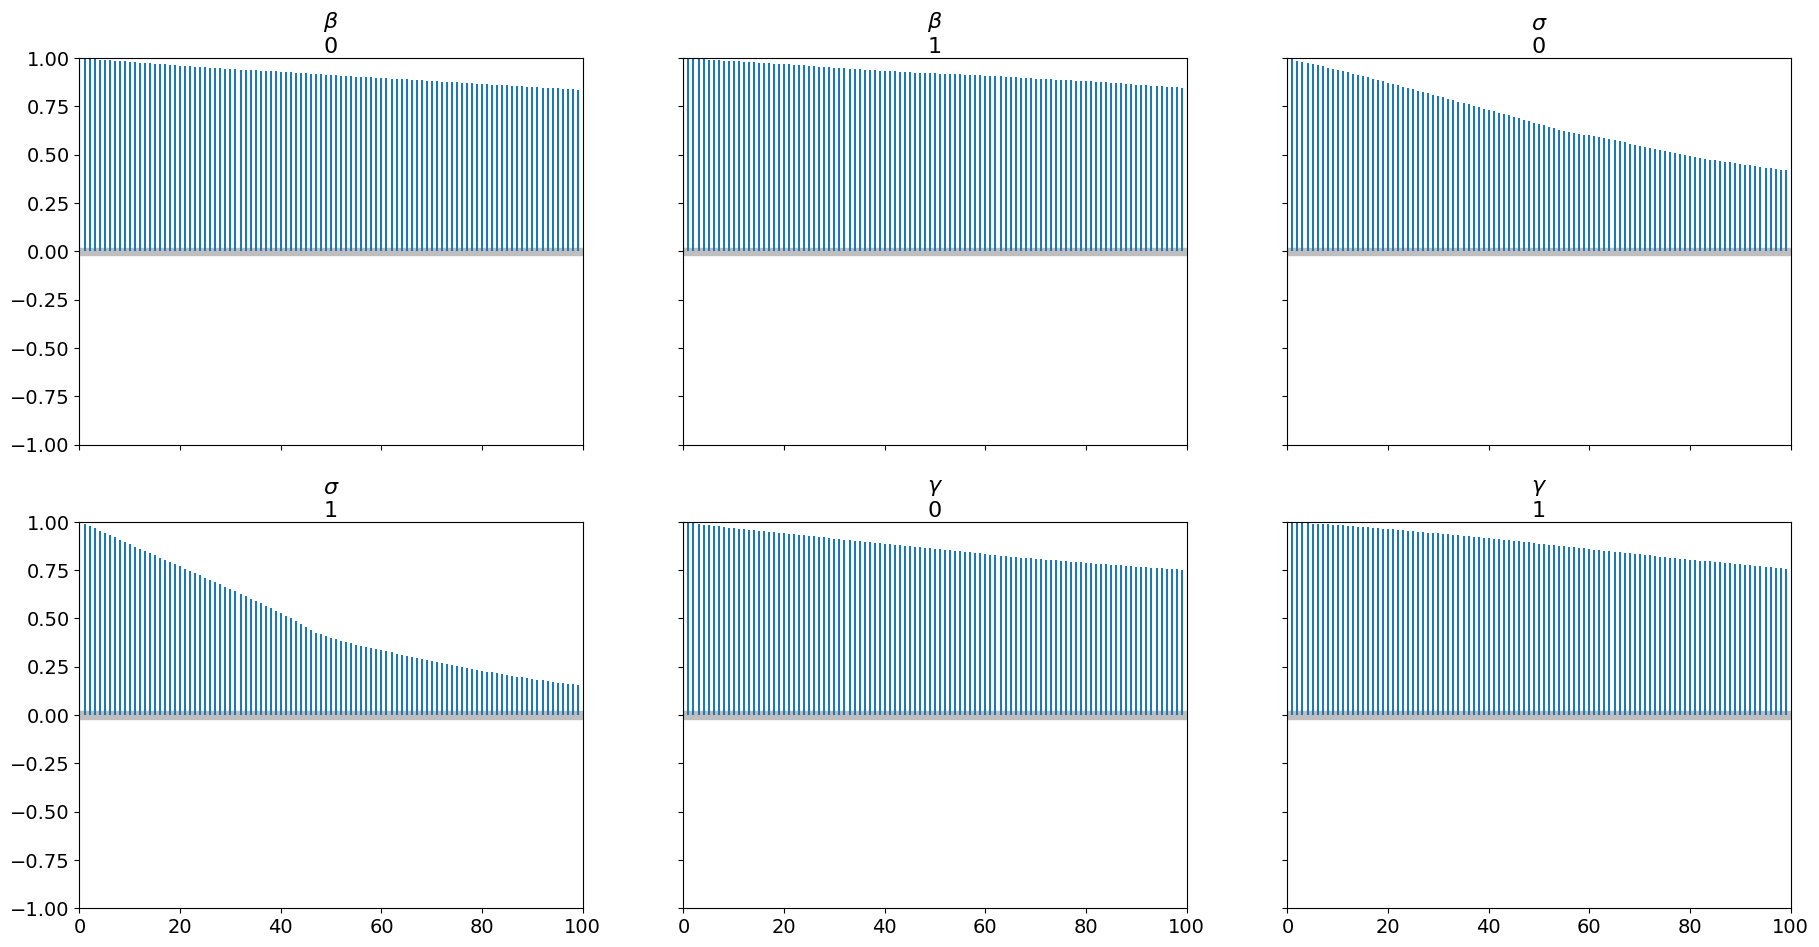

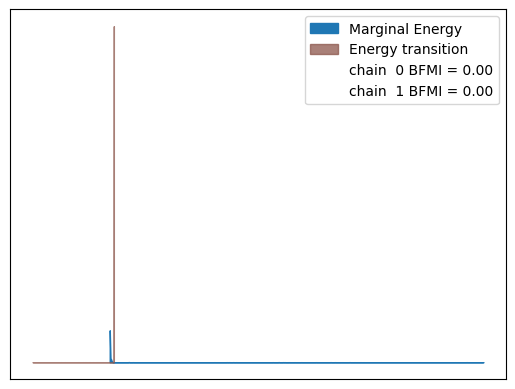

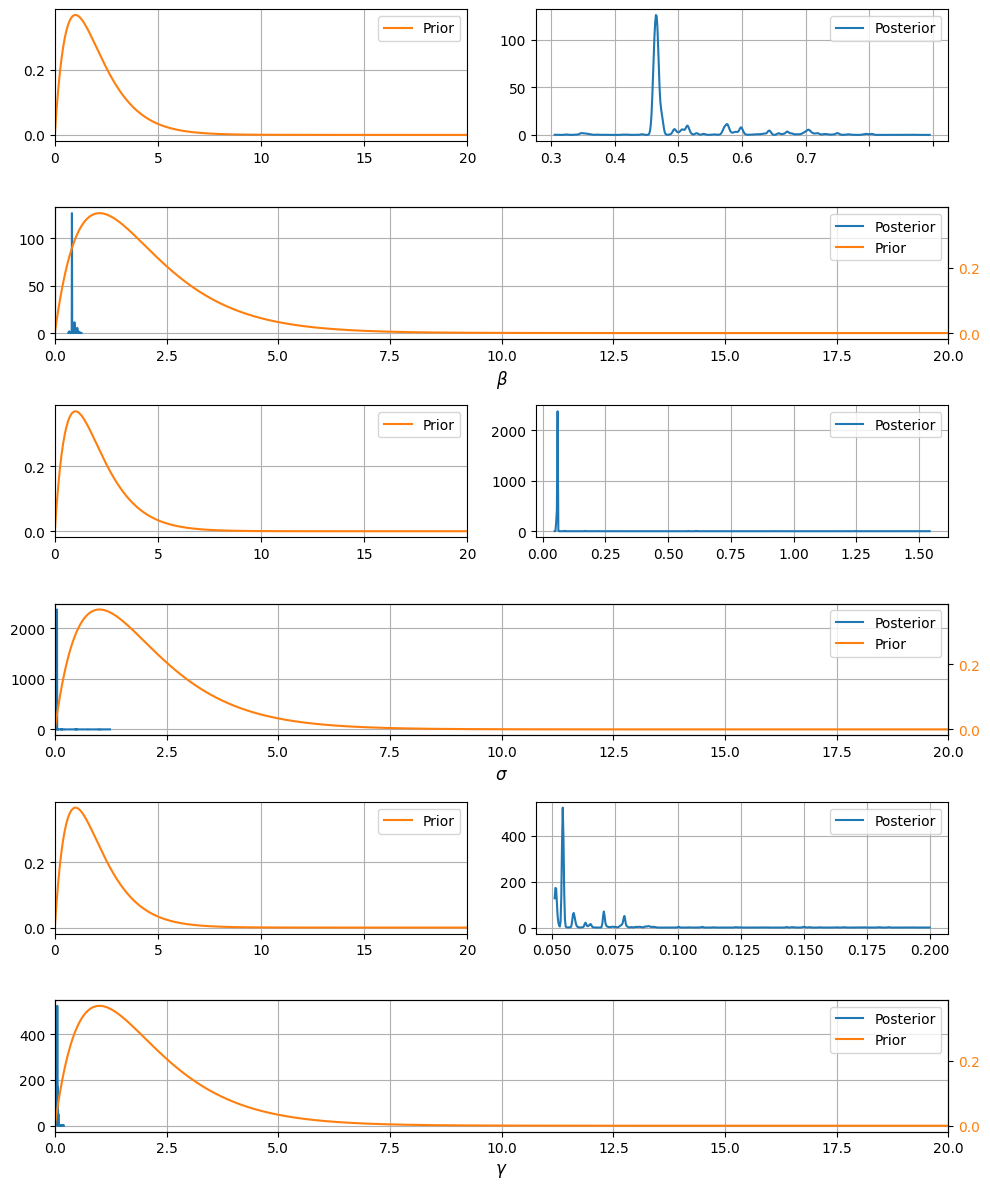

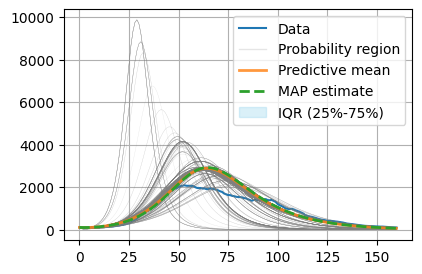

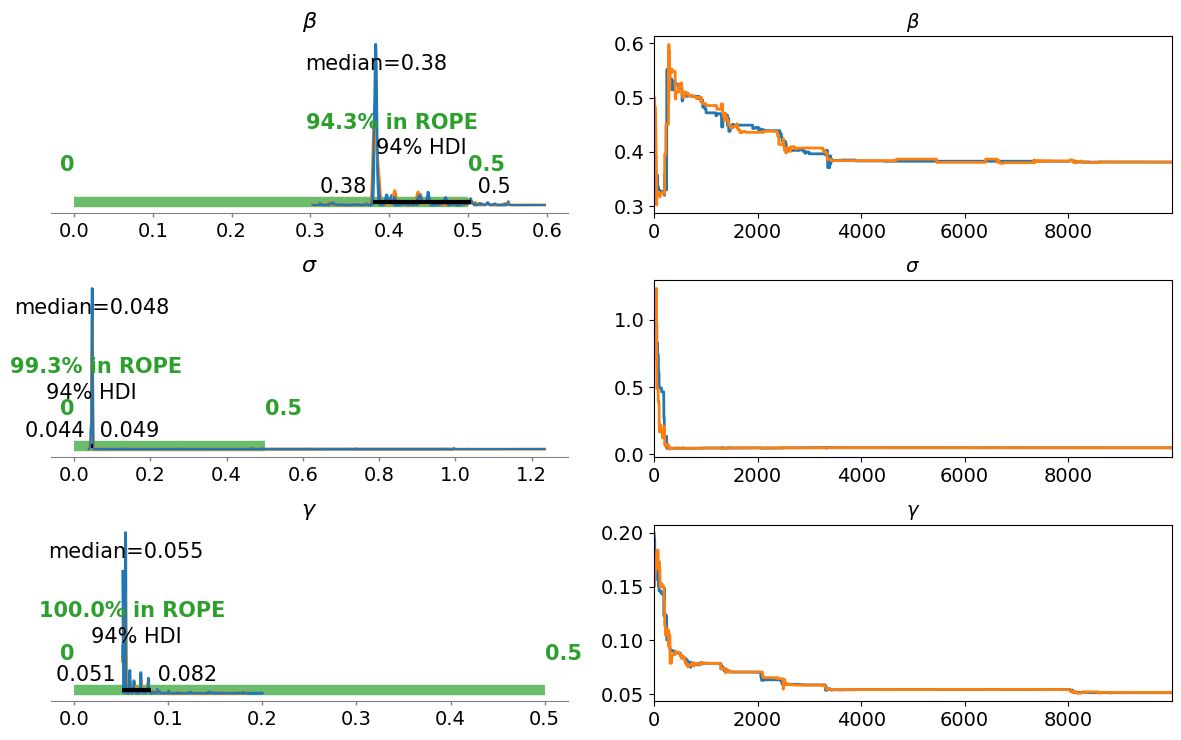

In [16]:
seir_twalk.create_dictionary()
seir_twalk.backend = 'matplotlib'
seir_twalk.report_results()

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.396  0.026   0.380    0.449      0.010    0.007       3.0      30.0   
sigma  0.047  0.001   0.046    0.049      0.000    0.000      11.0      30.0   
gamma  0.057  0.007   0.052    0.071      0.003    0.002       8.0       9.0   

       r_hat  
beta    1.65  
sigma   1.11  
gamma   1.22  


<Figure size 640x480 with 0 Axes>

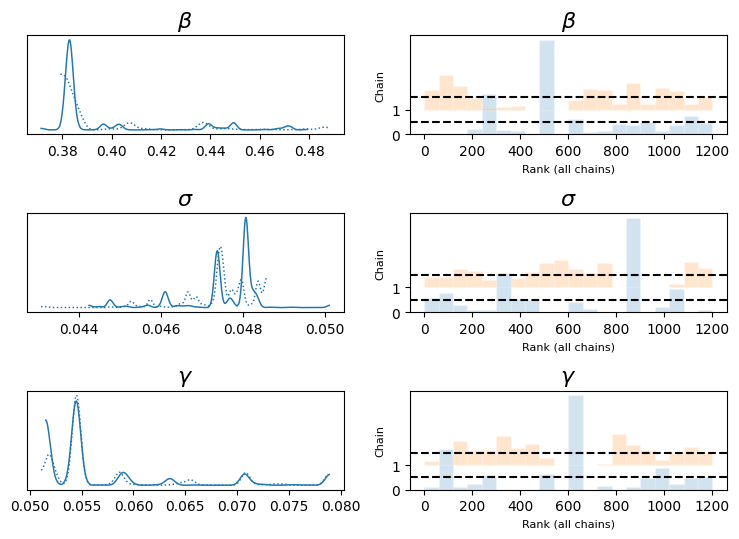

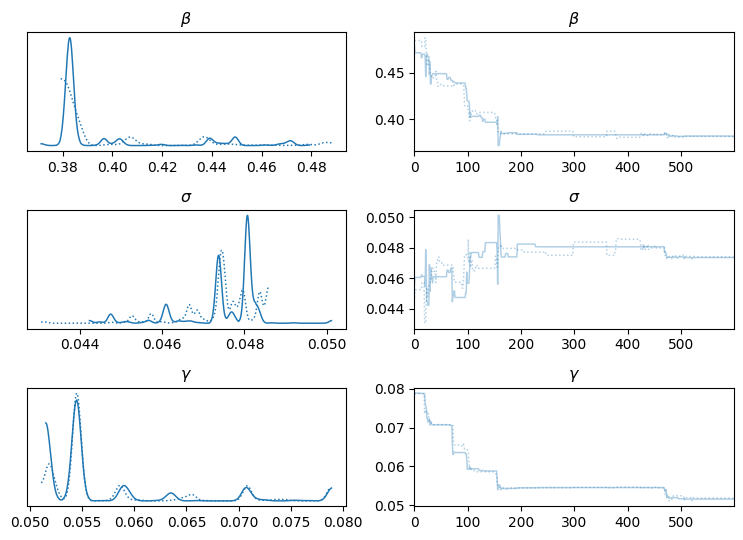

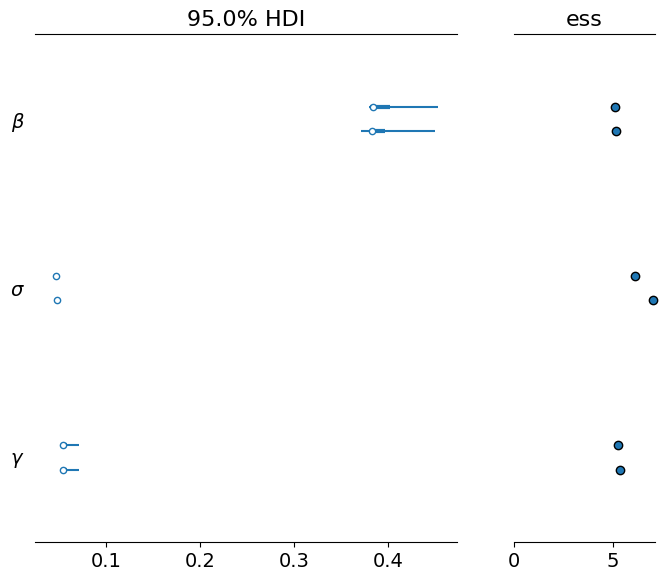

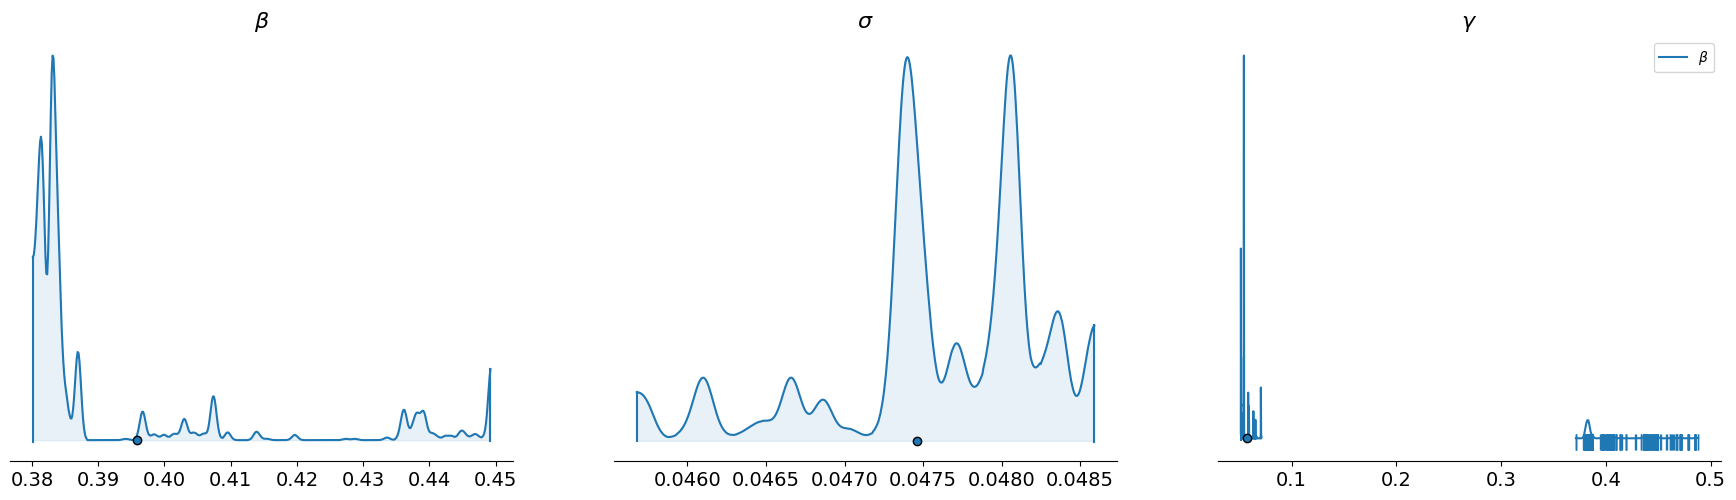

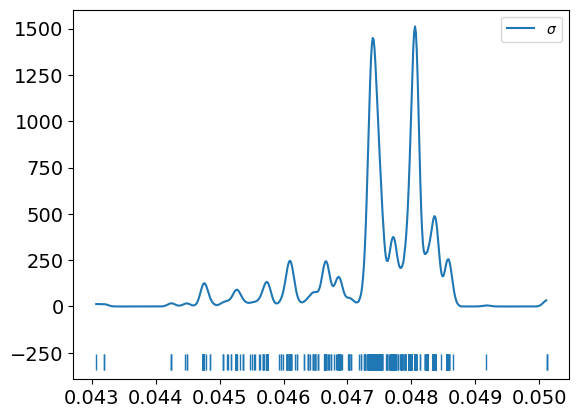

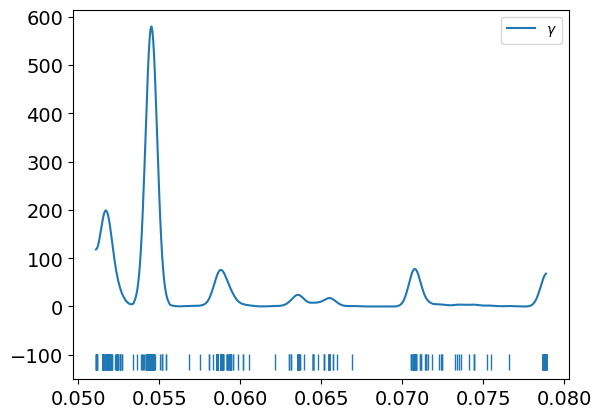

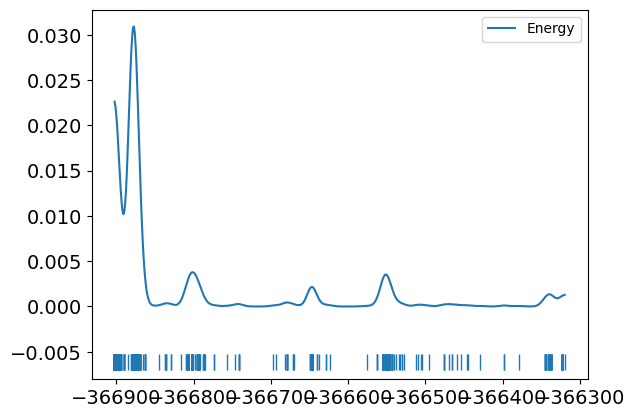

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 300 samples


100%|██████████| 600/600 [00:10<00:00, 56.32it/s]


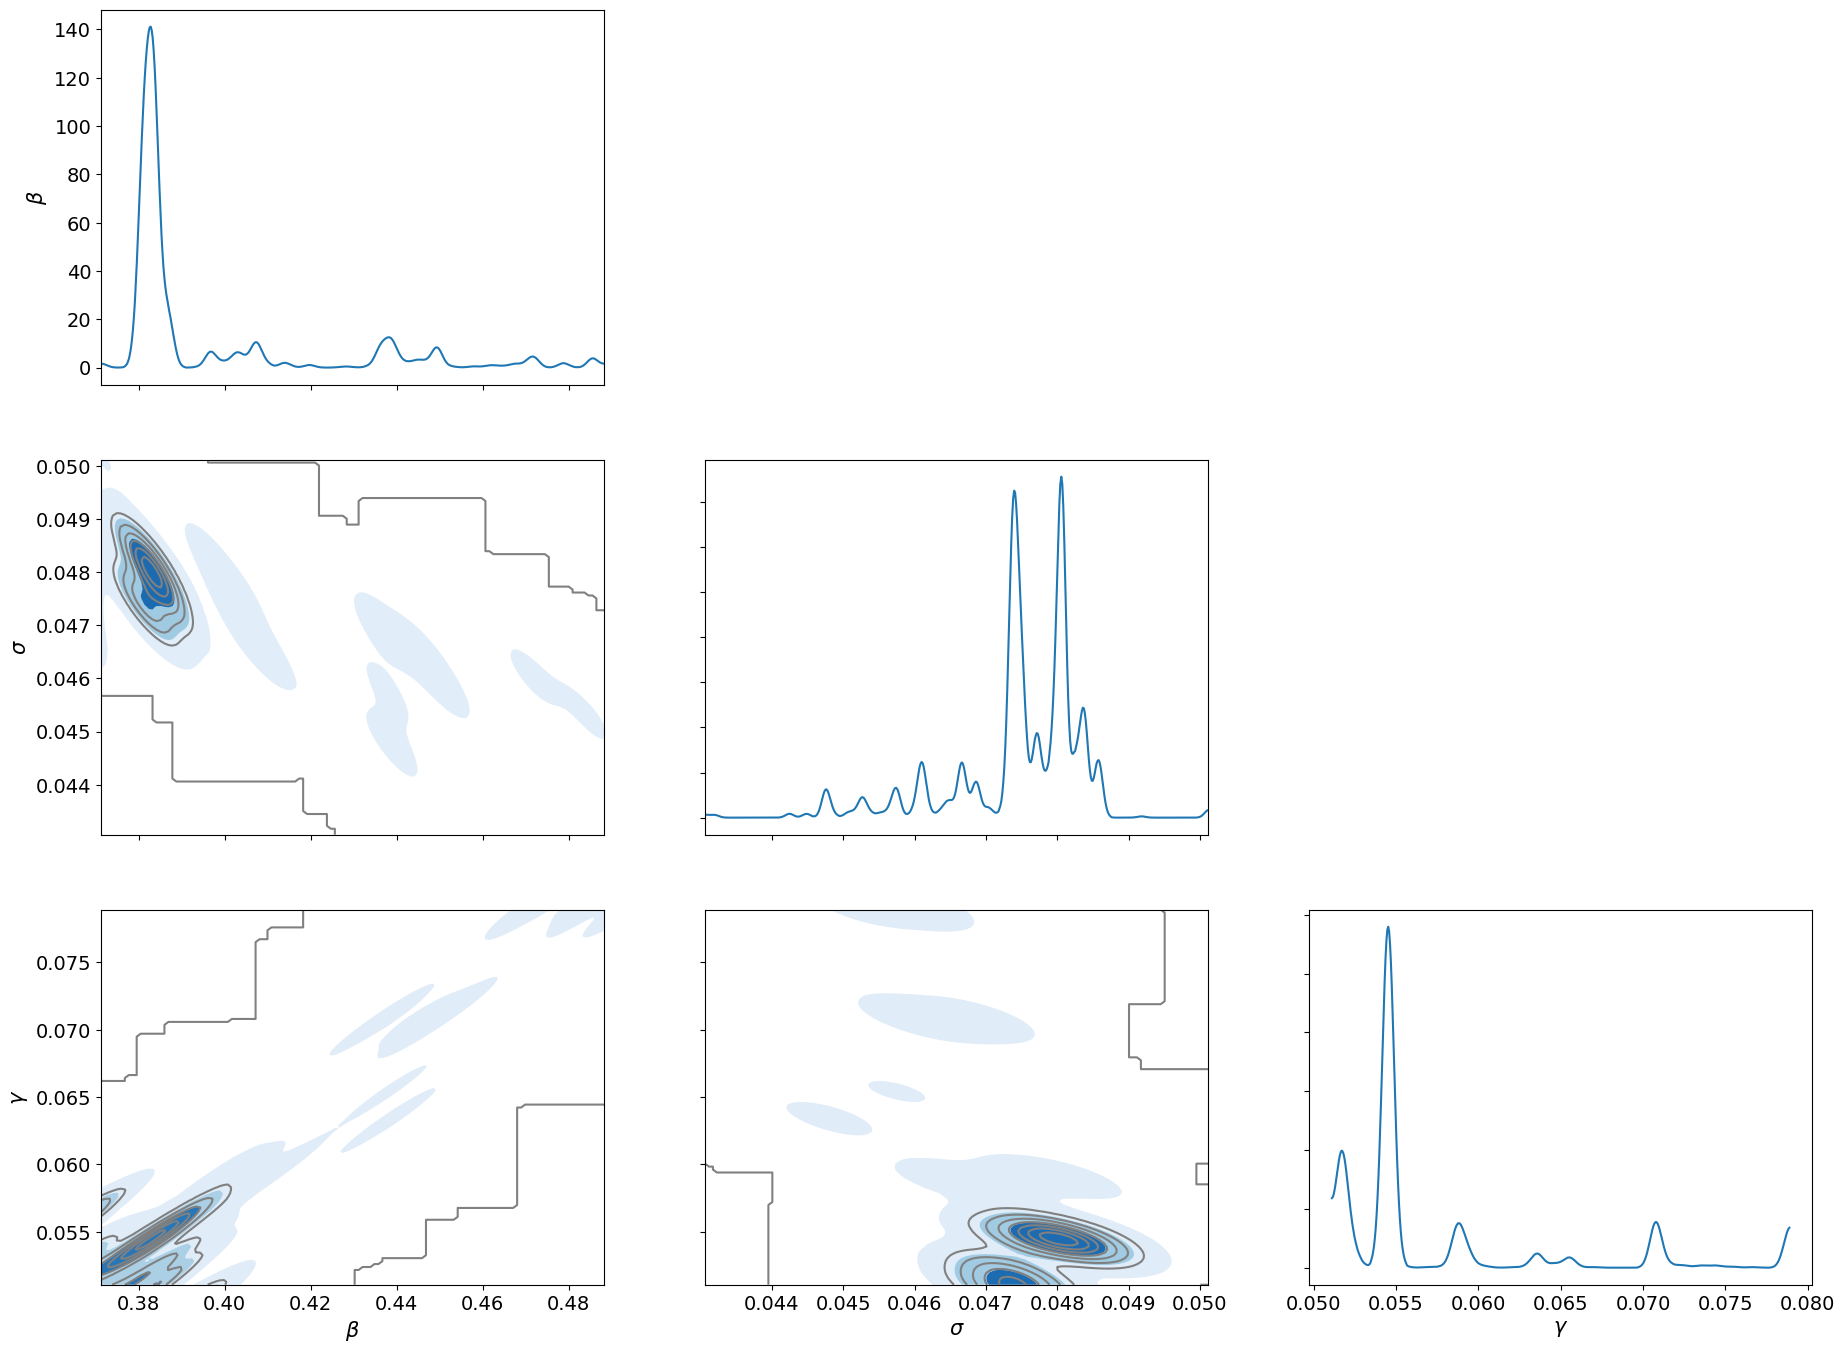

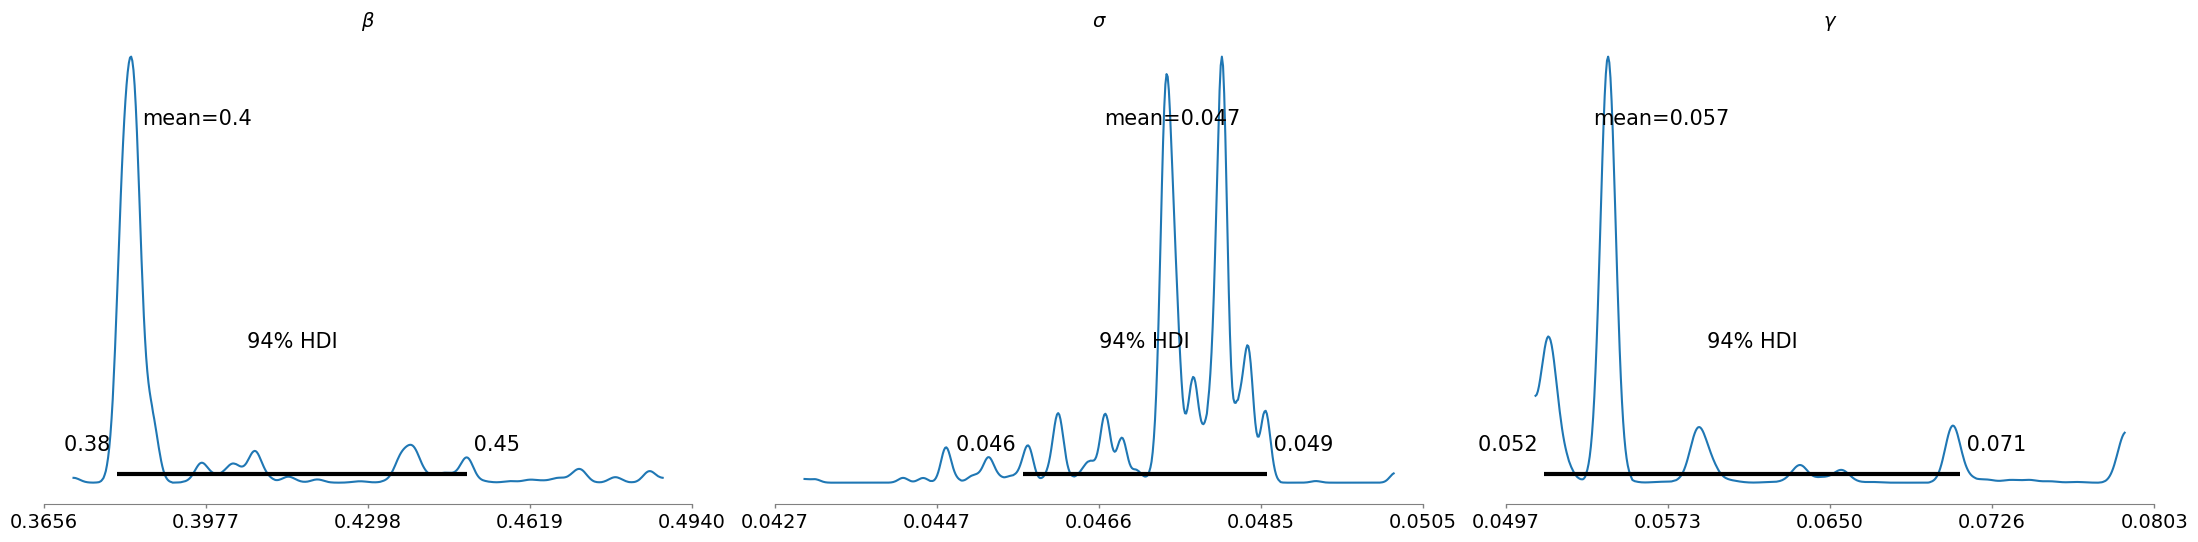

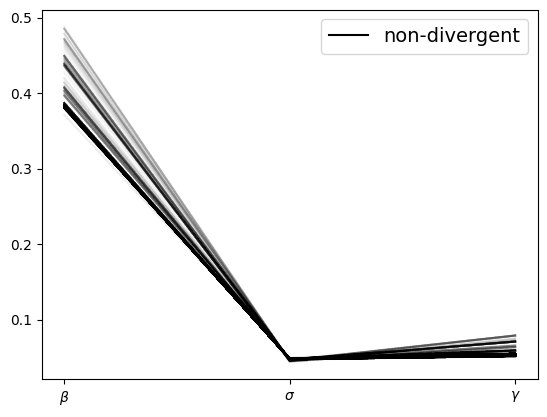

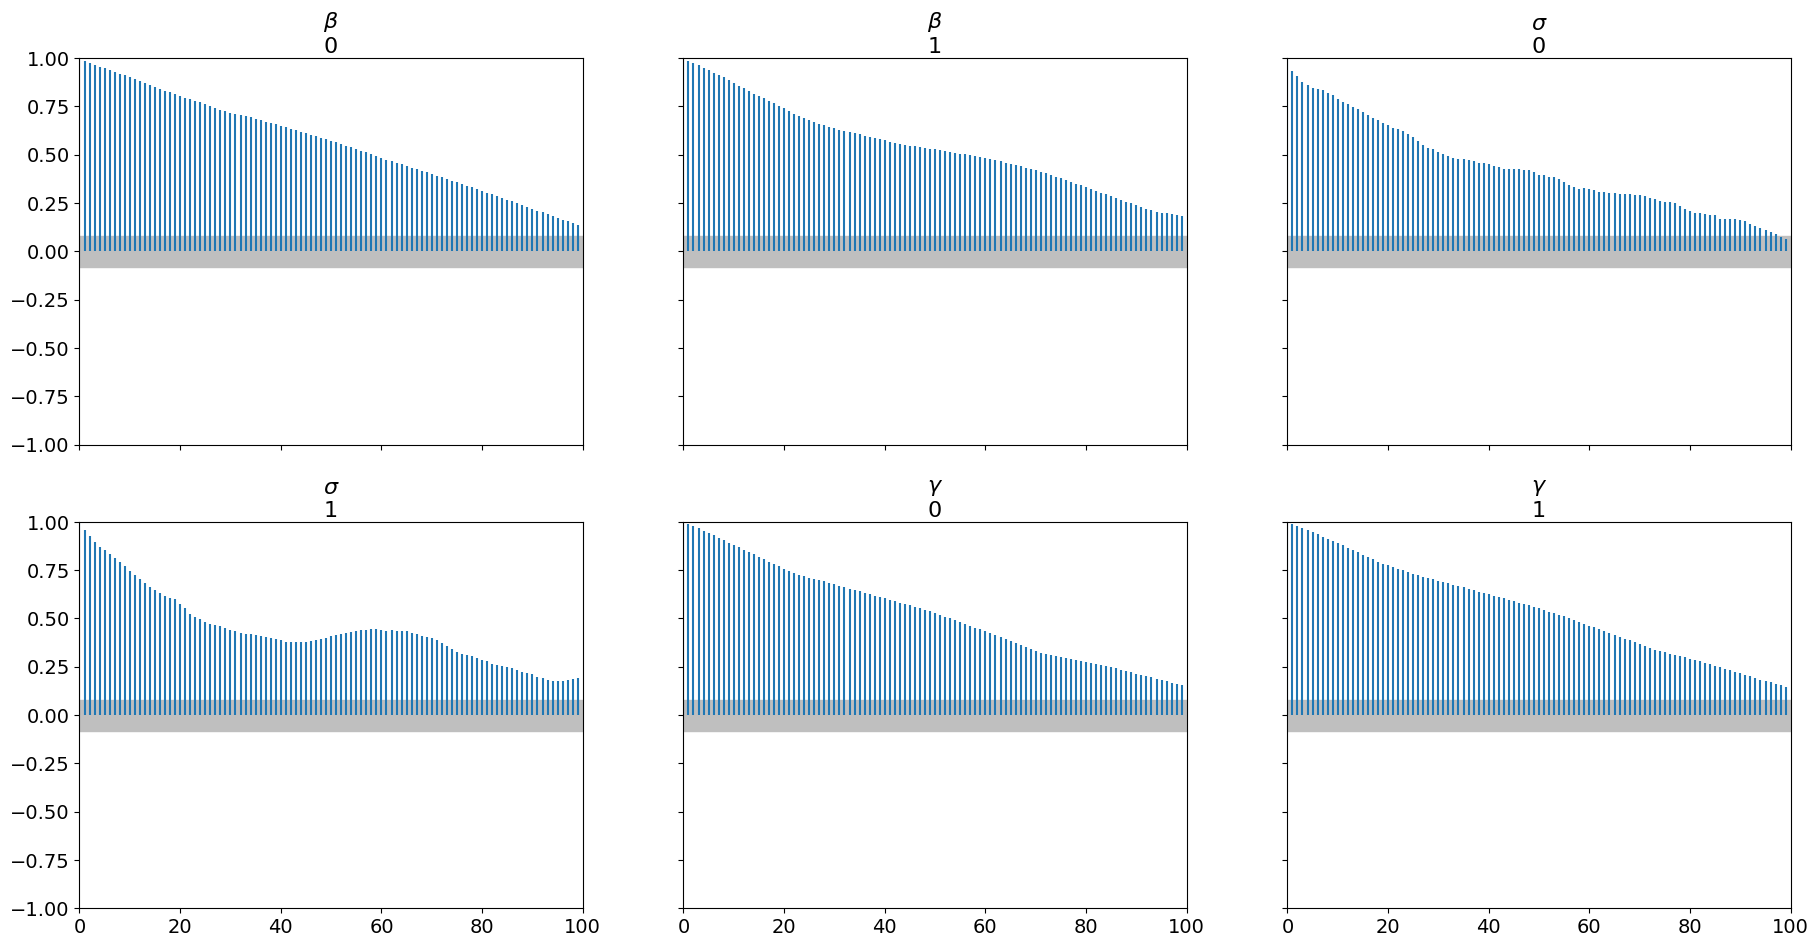

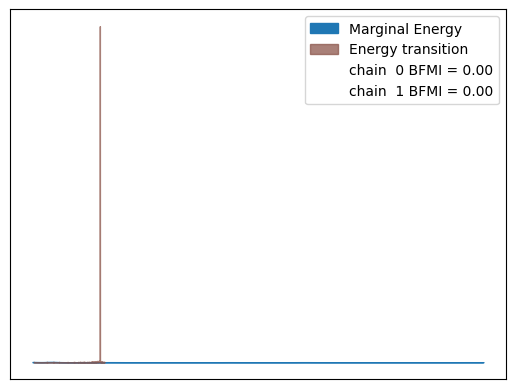

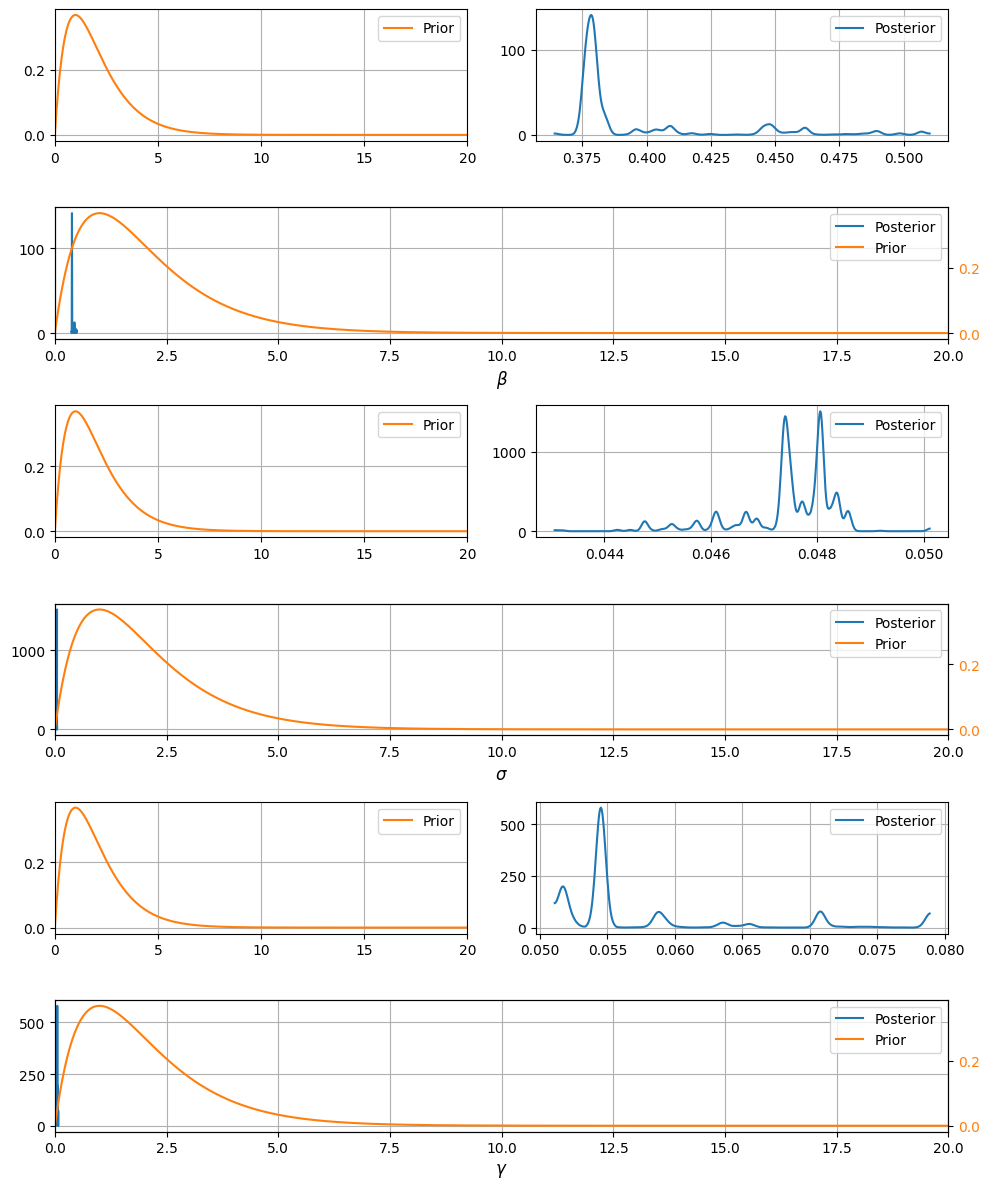

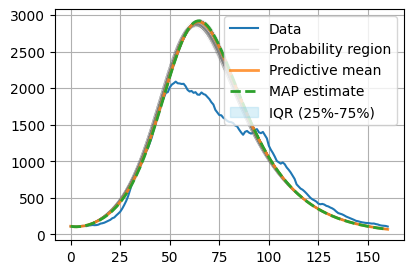

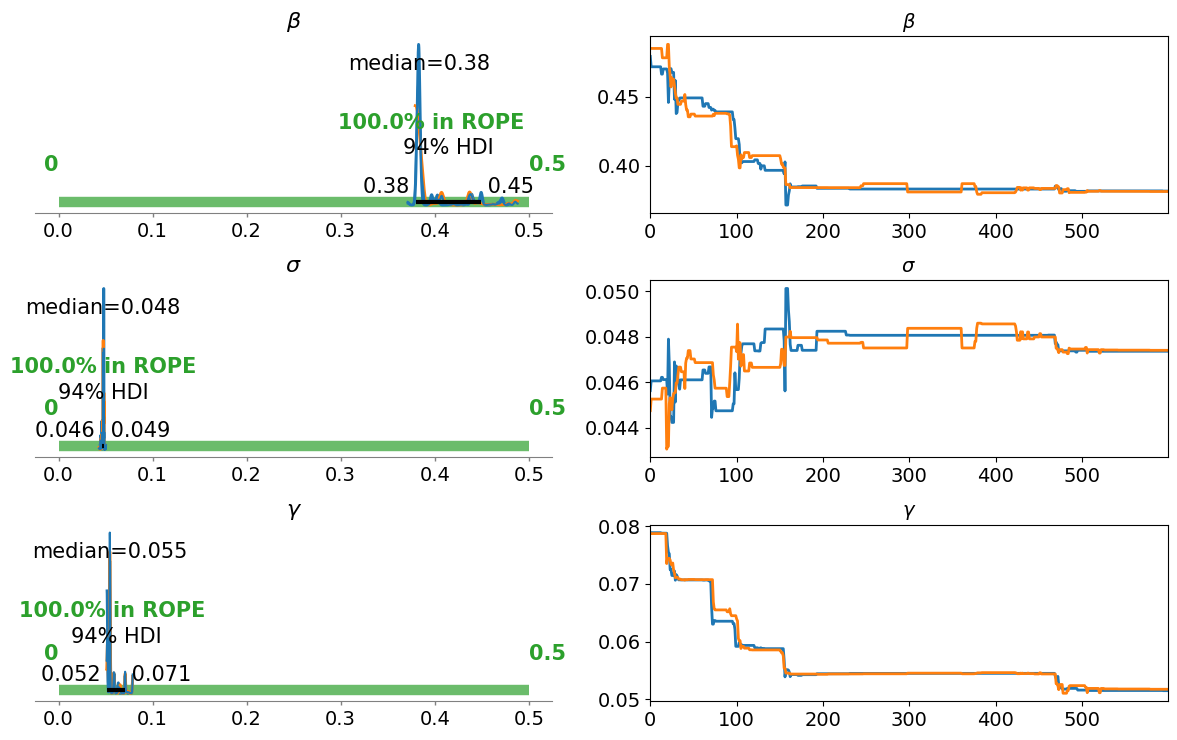

In [17]:
seir_twalk.create_dictionary(burnin=1000, subsample=15)

seir_twalk.report_results()

Using 300 samples


100%|██████████| 600/600 [00:10<00:00, 56.39it/s]


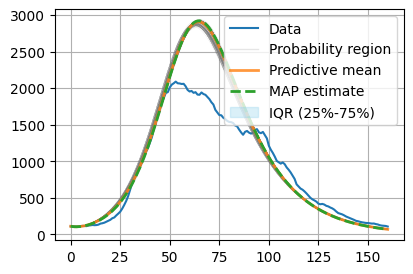

In [18]:
seir_twalk.plot_ppc()

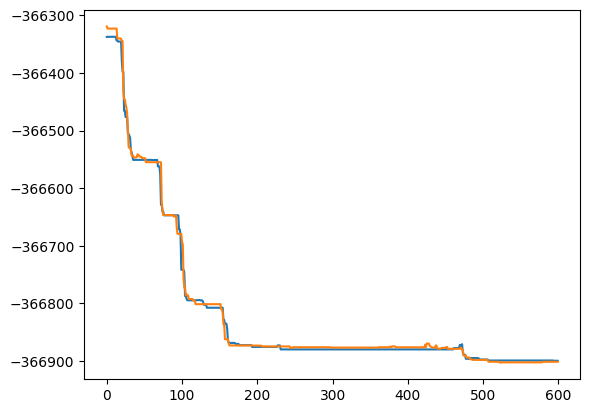

In [19]:
plt.plot(seir_twalk.idata.sample_stats.energy.values[:100].T)

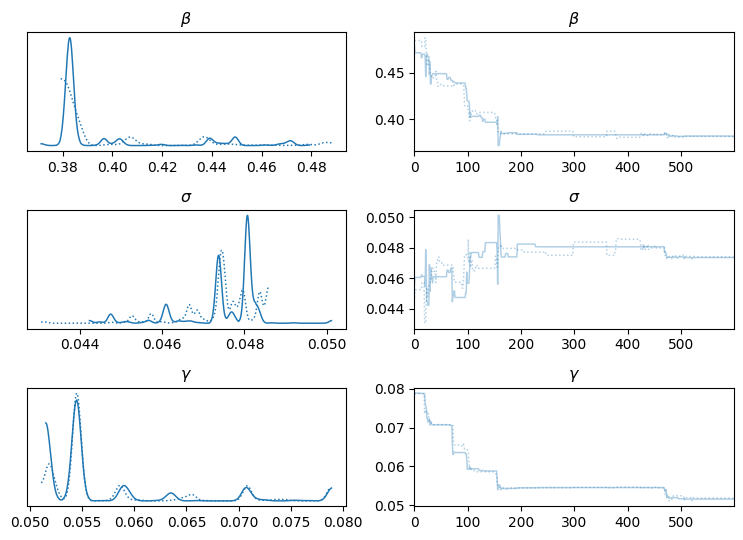

In [20]:
seir_twalk.plot_trace()

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

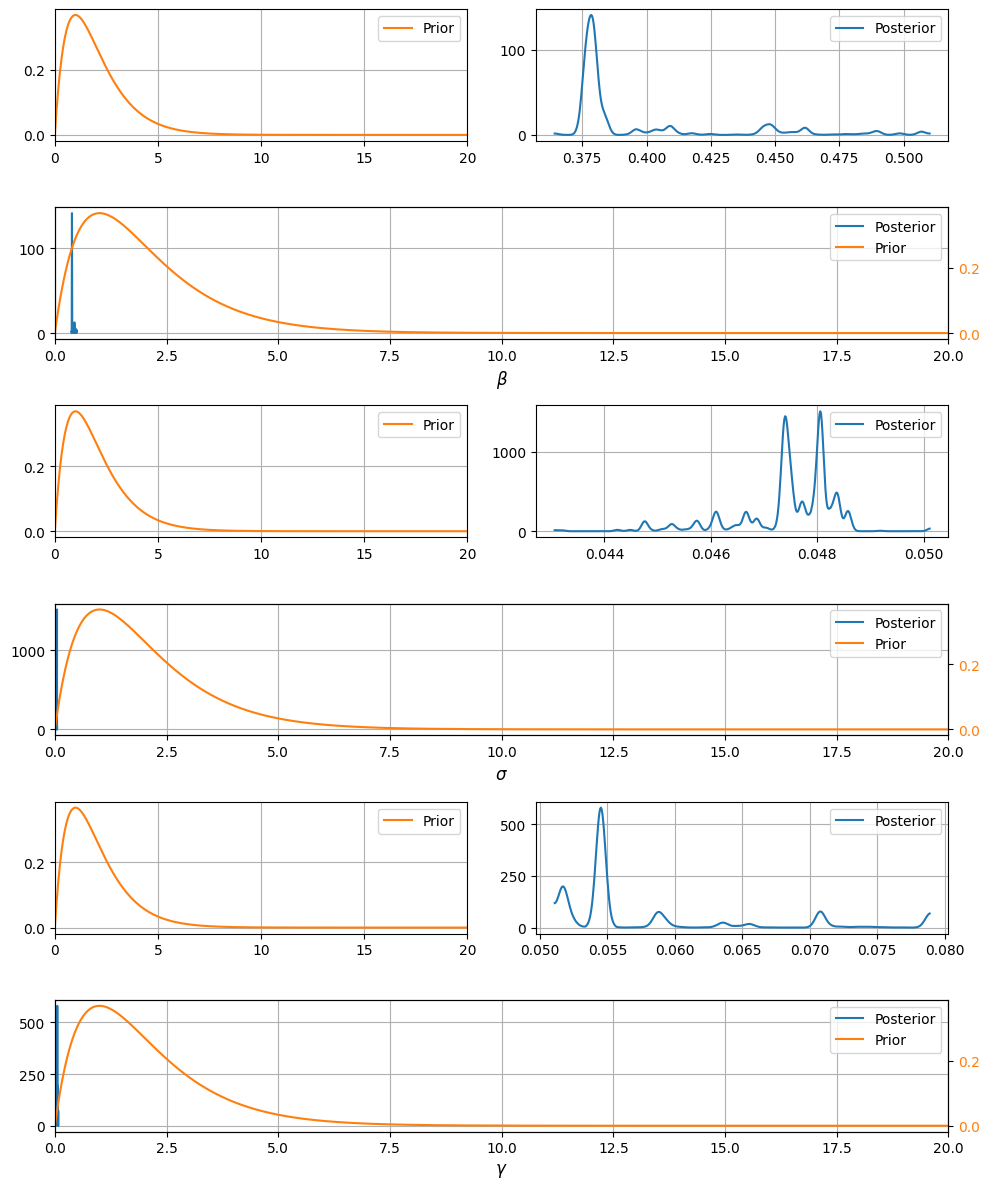

In [21]:
seir_twalk.plot_dist_comparison()

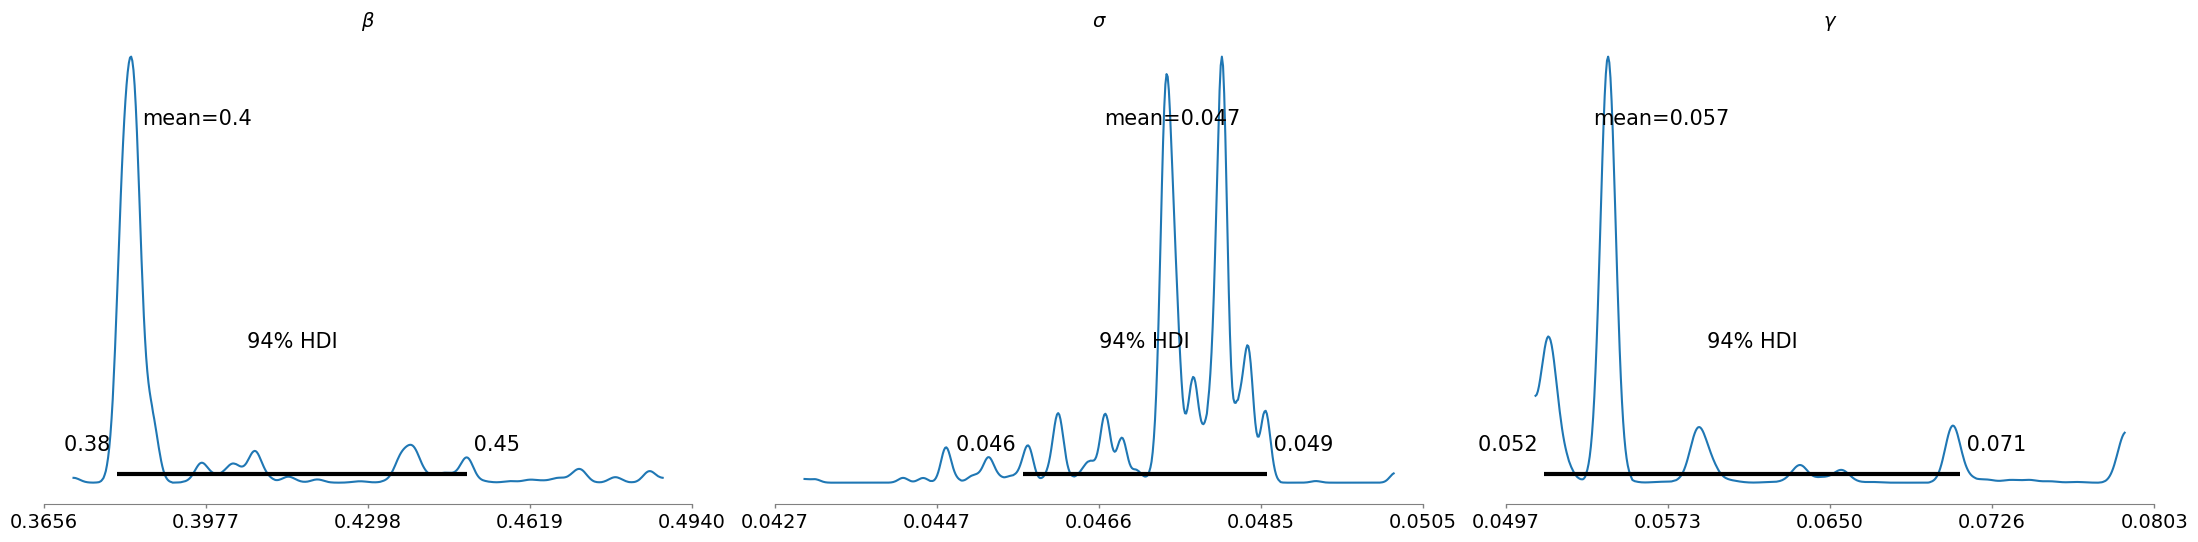

In [22]:
seir_twalk.plot_posterior()

In [24]:
seir_twalk.IAT()


AutoMaxlag: maxlag= 860.


matrix([[379.97201777]])